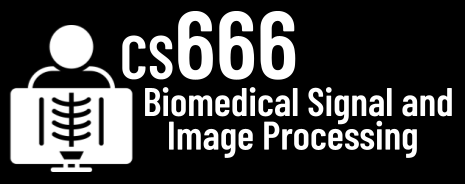
#Assignment 2

In [ ]:
### Luis González

In [1]:
%pylab inline
import os

Populating the interactive namespace from numpy and matplotlib


In [3]:
# we will be using the EEG/MEG analysis library MNE
# documentation is available here: https://mne.tools/stable/index.html
!pip install -U mne -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 53.8 MB/s eta 0:00:00


In [4]:
import mne # let's import MNE

# .. and the sample dataset
from mne.datasets import sample

# These data were acquired with the Neuromag Vectorview system at
# MGH/HMS/MIT Athinoula A. Martinos Center Biomedical Imaging.
# EEG data from an electrode cap was acquired simultaneously with the MEG.

### EXPERIMENT DESCRIPTION ###
# In this experiment, checkerboard patterns were presented to the subject into
# the left and right visual field, interspersed by tones to the left or right ear.
# The interval between the stimuli was 750 ms. Occasionally a smiley face was
# presented at the center of the visual field. The subject was asked to press a
# key with the right index finger as soon as possible after the appearance of the face.

In [5]:
# and let's load it!
data_path = sample.data_path()
raw = mne.io.read_raw_fif(os.path.join(data_path,'MEG/sample/sample_audvis_raw.fif'))

Using default location ~/mne_data for sample...
Creating /root/mne_data


  0%|                                              | 0.00/1.65G [00:00<?, ?B/s]

Untarring contents of '/root/mne_data/MNE-sample-data-processed.tar.gz' to '/root/mne_data'


Attempting to create new mne-python configuration file:
/root/.mne/mne-python.json
Could not read the /root/.mne/mne-python.json json file during the writing. Assuming it is empty. Got: Expecting value: line 1 column 1 (char 0)
Download complete in 01m41s (1576.2 MB)
Opening raw data file /root/mne_data/MNE-sample-data/MEG/sample/sample_audvis_raw.fif...
    Read a total of 3 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
    Range : 25800 ... 192599 =     42.956 ...   320.670 secs
Ready.


**Task 1:** Analyze the data. [20 Points]


In [14]:
# How many EEG channels were used when acquiring the data?
# Hint: You can use raw.info or raw.ch_names to figure this out!
eeg_channels = raw.info['nchan']
print(f'The number of channels is {eeg_channels}')

The number of channels is 376


In [18]:
# TODO What is the sampling frequency of this data?
sampling_freq = raw.info['sfreq']
print(f'The sampling frequency is {sampling_freq}')

The sampling frequency is 600.614990234375


In [19]:
# TODO What is the total duration of the measurement?
duration = len(raw.times) / sampling_freq
print(f'The total duration of the measurement is {duration} seconds')

The total duration of the measurement is 277.7153462901591 seconds


**Task 2:** Let's look at some channels! [20 Points]

Using matplotlib as 2D backend.


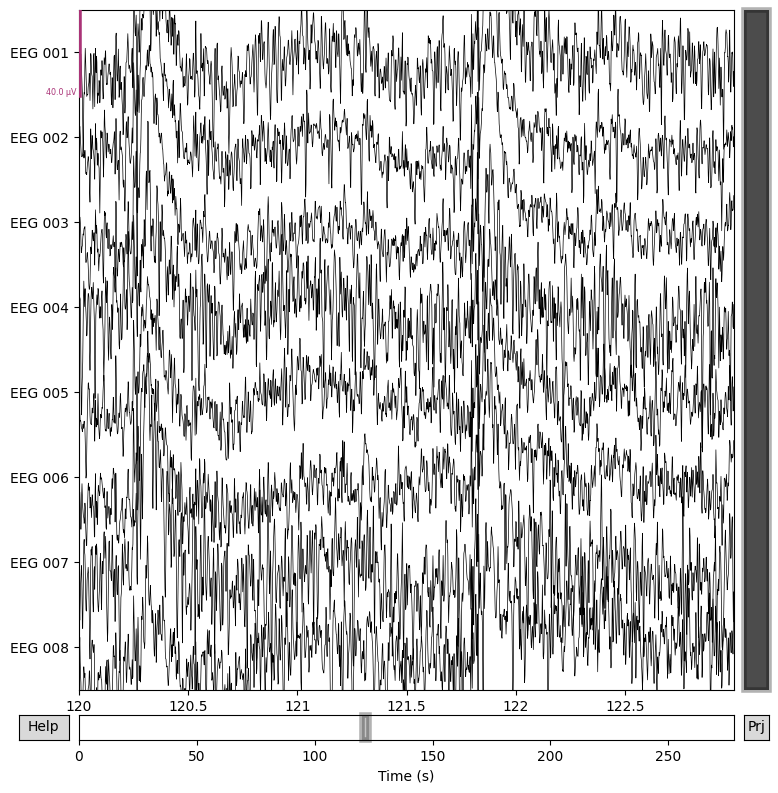

In [23]:
# the code below plots EEG channels 1-8 for 3 seconds after 2 minutes
chs = ['EEG 001', 'EEG 002', 'EEG 003', 'EEG 004', 'EEG 005', 'EEG 006', 'EEG 007', 'EEG 008']
chan_idxs = [raw.ch_names.index(ch) for ch in chs]
ecg1to8 = raw.plot(order=chan_idxs, start=120, duration=3)

In [ ]:
# TODO please plot EEG channels 50-60 for 1 second after 151 seconds.

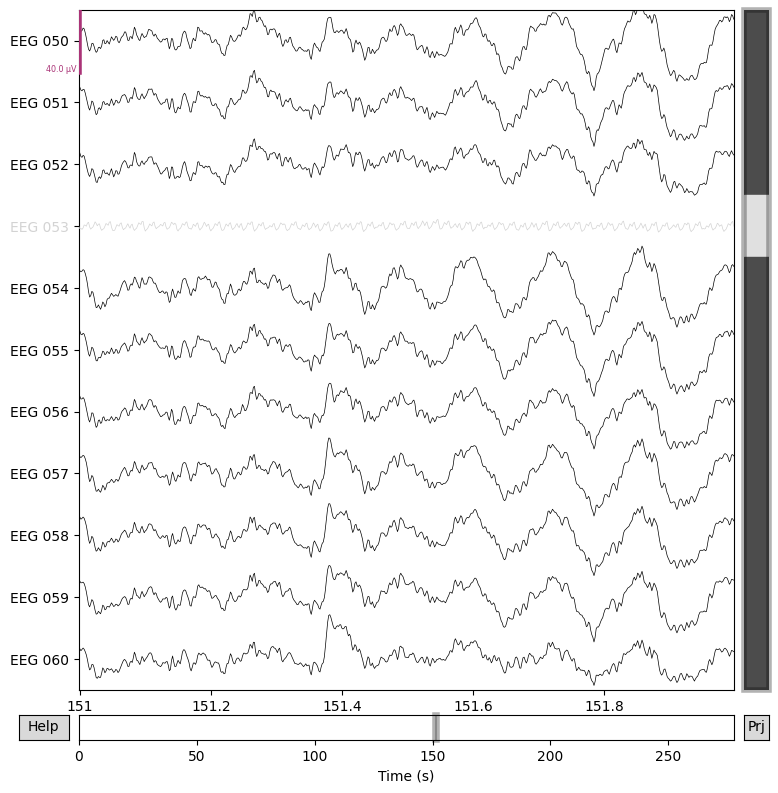

In [24]:
chs = [f'EEG {i:03d}' for i in range(50, 61)]
chan_idxs = [raw.ch_names.index(ch) for ch in chs]
ecg50to60 = raw.plot(order=chan_idxs, start=151, duration=1)

In [ ]:
# TODO: Do you see a bad channel? If yes, which one?
# Channel number 53. The amplitude is smaller than the others and it's been marked in gray

In [ ]:
# TODO: Please calculate the maximum value of the bad channel and compare it
# against a good channel. How would you detect a bad channel programmatically?
# Hint: See https://mne.tools/dev/generated/mne.io.Raw.html#mne.io.Raw to access
#       individual channels

In [29]:
bad_channel_name = 'EEG 053'
good_channel_name = 'EEG 054'

bad_channel_data, times = raw[bad_channel_name]
good_channel_data, _ = raw[good_channel_name]

max_bad = np.max(np.abs(bad_channel_data))
max_good = np.max(np.abs(good_channel_data))

print(f"Max value of {bad_channel_name} (Bad): {max_bad:.2e} V")
print(f"Max value of {good_channel_name} (Good): {max_good:.2e} V")

Max value of EEG 053 (Bad): 6.10e-05 V
Max value of EEG 054 (Good): 1.70e-04 V


In [56]:
# To detect the bad channels programatically, I would make a decision (threshold) based on the std of the channel.
# The bad channels seem to be very flat compared to the good channels
channel_data = raw.get_data(picks='eeg')
stds = np.std(channel_data, axis=1)

bad_flat_indices = np.where(stds < 1e-5)[0] + 306+9 # offset for EEG data
bad_flat_names = [raw.ch_names[i] for i in bad_flat_indices]
print(f"Bad channels (flat): {bad_flat_names}")

Bad channels (flat): ['EEG 053']


**Task 3:** How long between event and brain activity? [25 Points]

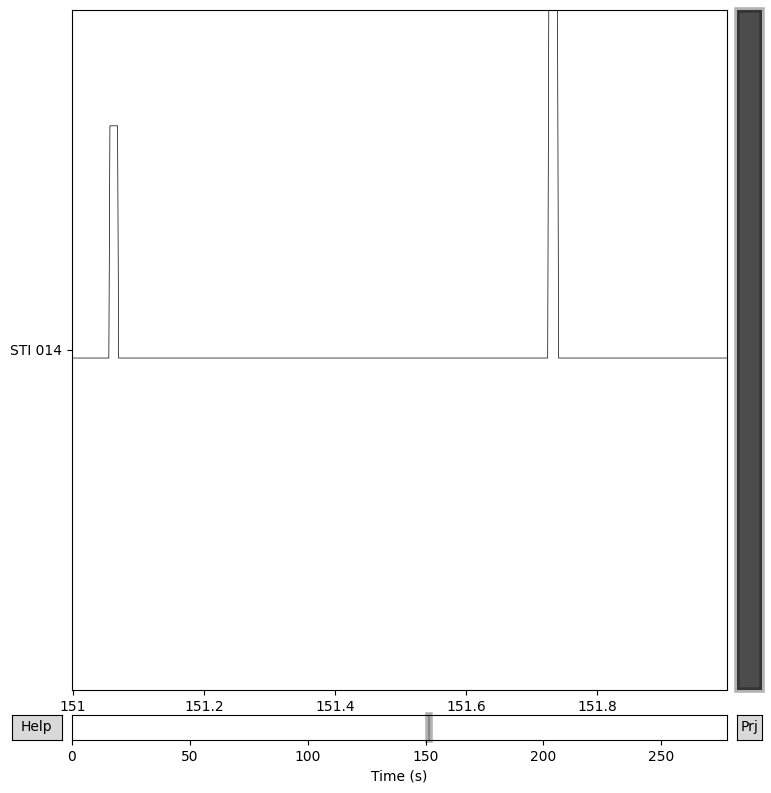

In [57]:
# the following code plots the stimulus channel for the same time
chan_idxs = [raw.ch_names.index('STI 014')]
stim = raw.plot(order=chan_idxs, start=151, duration=1)

In [ ]:
# TODO Please combine the last two plots into one.
# the plot should show EEG channels 50-60 and the stimulus channel together.

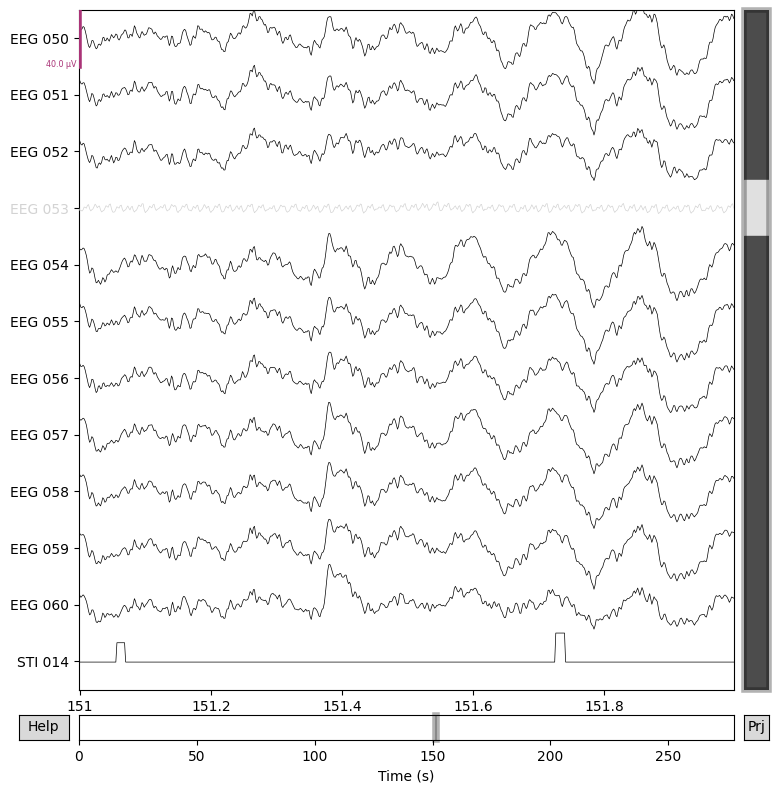

In [60]:
combined_names = [f'EEG {i:03d}' for i in range(50, 61)] + ['STI 014']
combined_idxs = [raw.ch_names.index(ch) for ch in combined_names]
_ = raw.plot(order=combined_idxs, start=151, duration=1, n_channels=len(combined_idxs))

In [ ]:
# TODO How many stimulus events do you observe?
# There are 2 stimulus events visible in the STI014 channel

In [ ]:
# TODO Please estimate the time between the first stimulus and brain activity response.
# The first pulse on ST 014 begins at approximately 151.05 seconds and a clear,
# synchronized upward deflection is visible across multiple channels starting at approximately 151.38 seconds.
# Therefore: 151.38s - 151.05s = 0.33s

**Task 4:** Localize different brain waves for different stimuli! [35 Points]

In [61]:
# the following code groups all stimuli together
# and allows the visualization of average brain activity per stimuli.
events = mne.find_events(raw, stim_channel='STI 014')
event_dict = {'auditory/left': 1,
              'auditory/right': 2,
              'visual/left': 3,
              'visual/right': 4,
              'face': 5,
              'button': 32}

picks = mne.pick_types(raw.info, eeg=True)

epochs = mne.Epochs(raw, events, event_id=event_dict, picks=picks,
                    preload=True)

Finding events on: STI 014
320 events found on stim channel STI 014
Event IDs: [ 1  2  3  4  5 32]
Not setting metadata
320 matching events found
Setting baseline interval to [-0.19979521315838786, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Loading data for 320 events and 421 original time points ...
0 bad epochs dropped


NOTE: plot_psd_topomap() is a legacy function. New code should use .compute_psd().plot_topomap().
    Using multitaper spectrum estimation with 7 DPSS windows
Averaging across epochs before plotting...


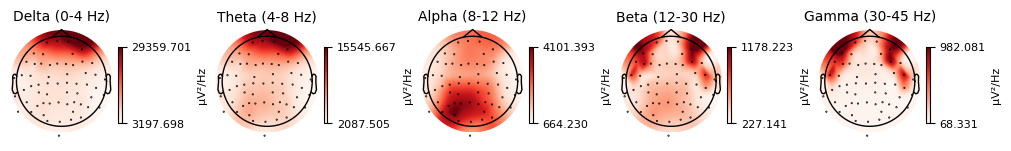

In [62]:
# here we see the average localized brain activity for the right visual stimuli
visual_activity = epochs['visual/right'].plot_psd_topomap()

NOTE: plot_psd_topomap() is a legacy function. New code should use .compute_psd().plot_topomap().
    Using multitaper spectrum estimation with 7 DPSS windows
Averaging across epochs before plotting...


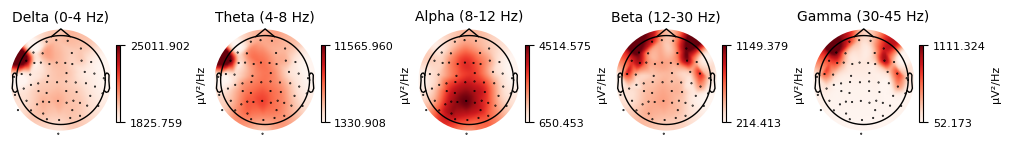

In [63]:
# here we see the average localized brain activity for the shown 'face'
face_activity = epochs['face'].plot_psd_topomap()

In [ ]:
# TODO The above plots use a deprecated API call. Please re-create both plots here with the newer API.

    Using multitaper spectrum estimation with 7 DPSS windows
Averaging across epochs before plotting...


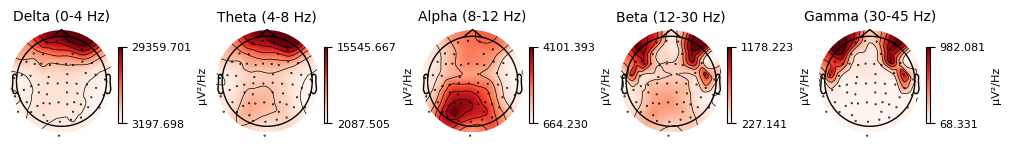

    Using multitaper spectrum estimation with 7 DPSS windows
Averaging across epochs before plotting...


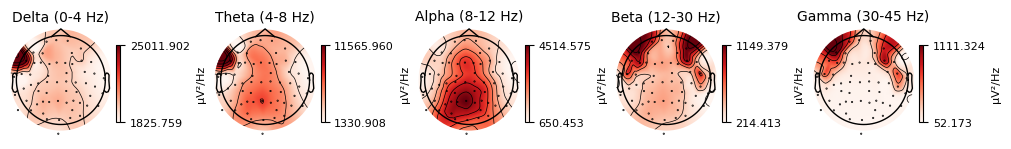

In [64]:
psd_visual_right = epochs['visual/right'].compute_psd()
visual_activity = psd_visual_right.plot_topomap()

psd_face = epochs['face'].compute_psd()
face_activity = psd_face.plot_topomap()

In [ ]:
# TODO Now compare the two old plots with the new ones. What are the differences?
# The new plots overlay black contour lines that connect points of equal power density.

In [ ]:
# TODO Please visualize the average brain activity when the subject pushes the button

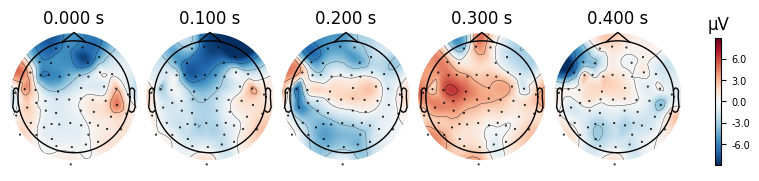

No projector specified for this dataset. Please consider the method self.add_proj.


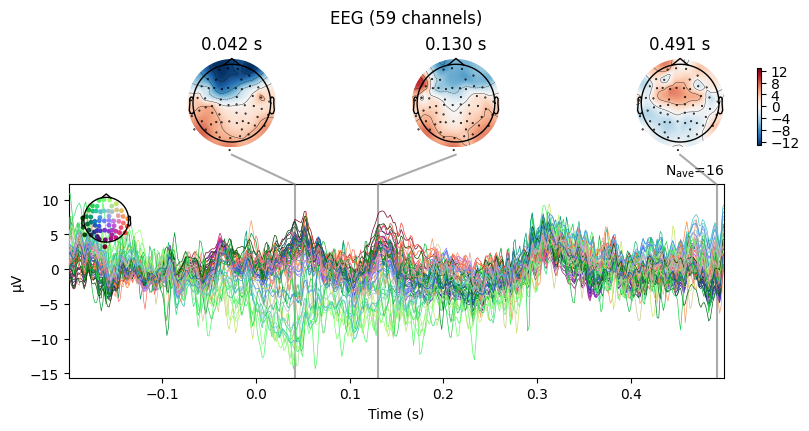

In [69]:
button_evoked = epochs['button'].average()

times = [0.0, 0.1, 0.2, 0.3, 0.4]
_ = button_evoked.plot_topomap(times=times, ch_type='eeg', colorbar=True)

_ = button_evoked.plot_joint(picks='eeg')

In [71]:
# TODO Which difference do you see between the visual/right, the face, and the button event?
# TODO Which brain region seems active during the button event?
# Hint: visual/right and face seem more similar to the button event. Think about why?

# The primary difference between the conditions is that visual/right and face represent sensory input,
# whereas the button event represents a motor output. During the button event, the potential topomaps reveal
# distinct activity in the central and left-lateralized central scalp regions. The visual/right and face events are highly similar to each other,
# and different from the button event, because they both involve stimulus visual processing and the topomaps reveal activity concentrated in the
# posterior, occipital, and parietal regions of the scalp

**Bonus Task:** What type of event happened in Task 3? [33 Points]

In [ ]:
# TODO Please go back to Task 3. Can you figure out which event types happened?

In [75]:
events = mne.find_events(raw, stim_channel='STI 014')

event_mapping = epochs.event_id
print("Event name mapping:", event_mapping)

Finding events on: STI 014
320 events found on stim channel STI 014
Event IDs: [ 1  2  3  4  5 32]
Event name mapping: {'auditory/left': 1, 'auditory/right': 2, 'visual/left': 3, 'visual/right': 4, 'face': 5, 'button': 32}


In [ ]:
# You did it!!
#
# ┈┈┈┈┈┈▕▔╲
# ┈┈┈┈┈┈┈▏▕
# ┈┈┈┈┈┈┈▏▕▂▂▂
# ▂▂▂▂▂▂╱┈▕▂▂▂▏
# ▉▉▉▉▉┈┈┈▕▂▂▂▏
# ▉▉▉▉▉┈┈┈▕▂▂▂▏
# ▔▔▔▔▔▔╲▂▕▂▂|
#